# Rice Grain Classification Using Logistic Regression
## 1. Data Exploration 

In [1]:
# Install this to load the dataset .arff file
!pip install liac-arff

In [2]:
import arff
import pandas as pd

with open('Rice_Cammeo_Osmancik.arff', 'r') as f:
    dataset = arff.load(f)

# Extract attributes for column names and data for rows
columns = [attr[0] for attr in dataset['attributes']]
df = pd.DataFrame(dataset['data'], columns=columns)
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


Now we can explore the dataset's attributes.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   str    
dtypes: float64(5), int64(2), str(1)
memory usage: 264.8 KB


In [4]:
df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

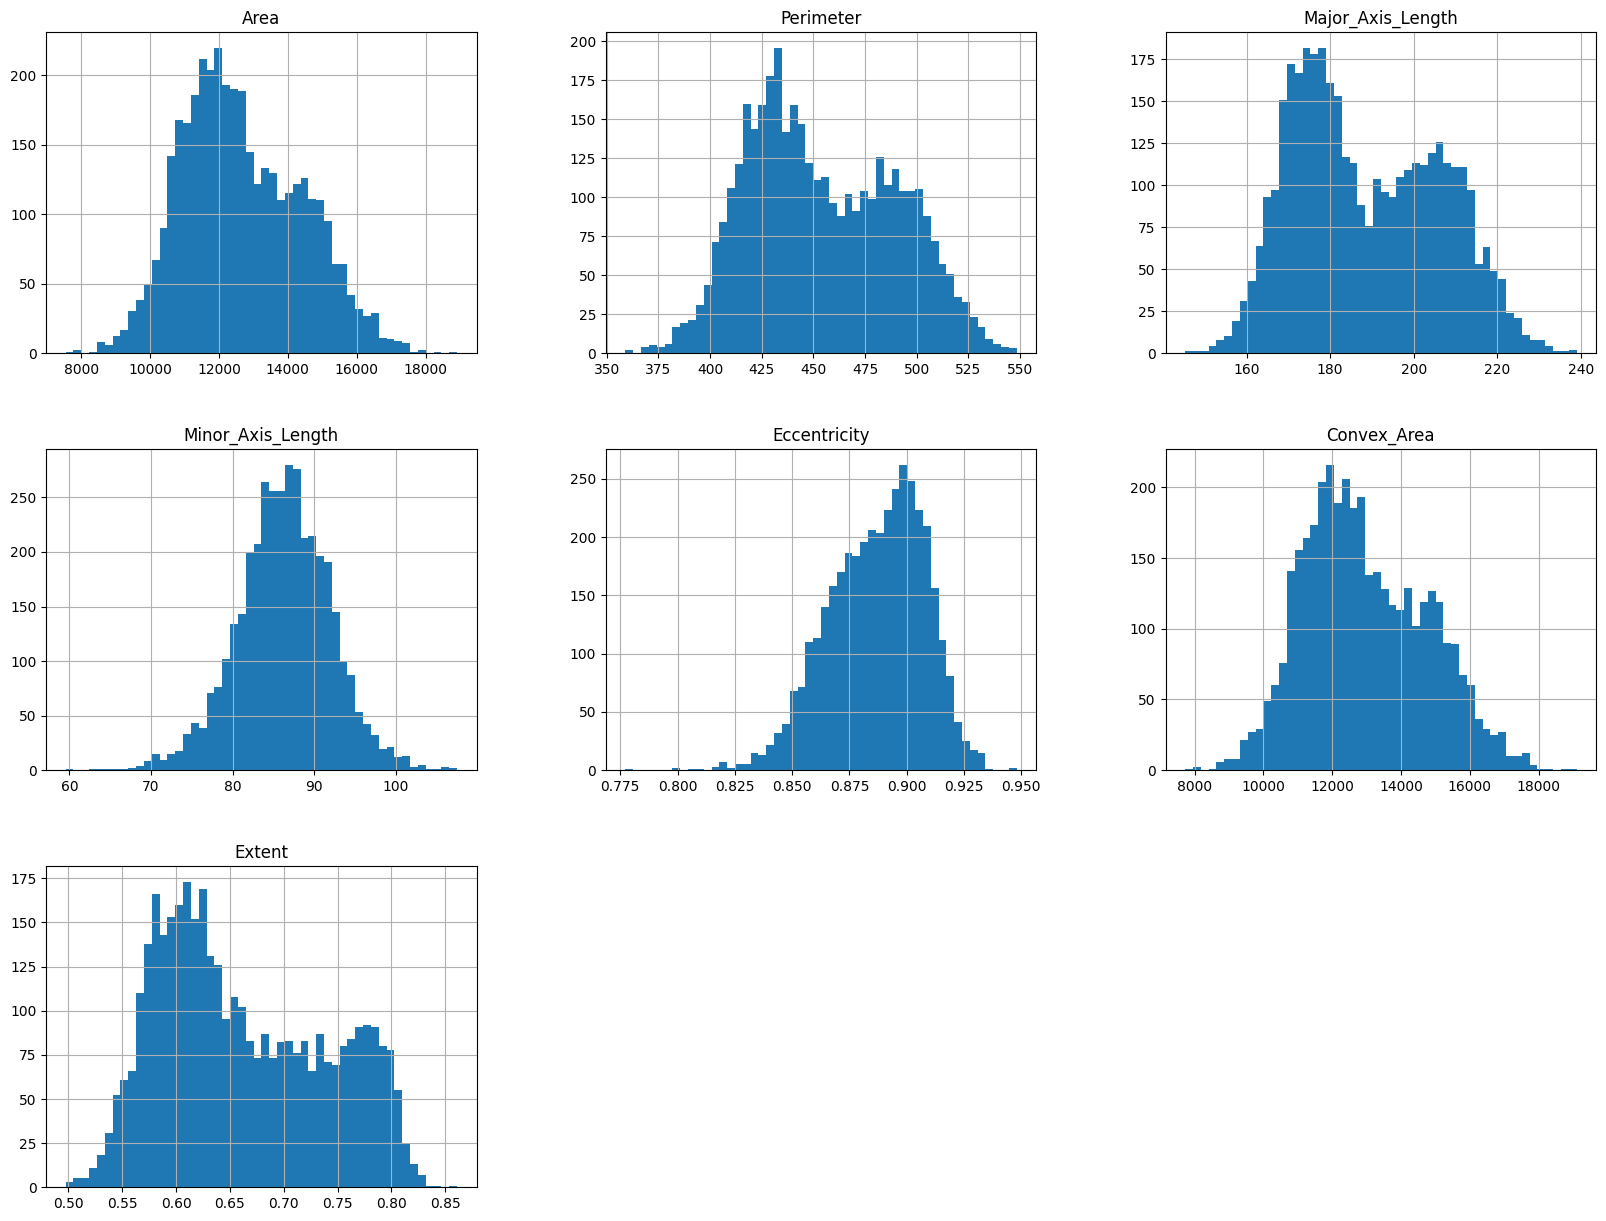

In [6]:
df.hist(bins=50, figsize=(20,15))
plt.show()

In [7]:
# Displays total counts for each unique label in the Class column
df['Class'].value_counts()

Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64

C:\Users\peter\AppData\Local\Temp\ipykernel_3104\2845177710.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='Set2')


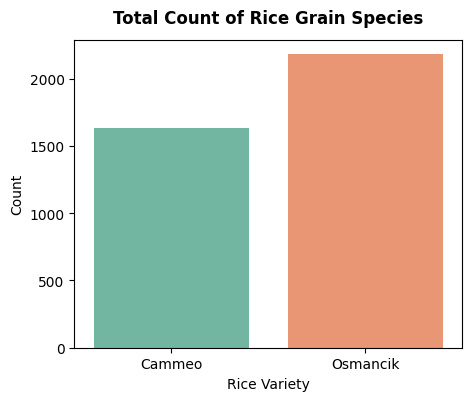

In [8]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Class', palette='Set2')

plt.title('Total Count of Rice Grain Species', fontsize=12, pad=12, fontweight='bold')
plt.xlabel('Rice Variety')
plt.ylabel('Count')

plt.show()

## 2. Pre-Processing

In [9]:
X = df.drop(columns=['Class'])
y = df['Class']
# Convert text classes ('Cammeo', 'Osmancik') into 1s and 0s
y = y.map({'Osmancik': 0, 'Cammeo': 1})

## 3. Splitting the dataset into Training and Testing Sets

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # Ensures you get the exact same split every time you run it
    stratify=y          # Maintains class balance in both splits
)

## 4. Scaling the features

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler ONLY on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the SAME scaler (do not re-fit!)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Check if our feature scaling worked correctly
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")
print(f"Class distribution in training set:\n{y_train.value_counts(normalize=True)}")

Training features shape: (3048, 7)
Testing features shape: (762, 7)
Class distribution in training set:
Class
0    0.572178
1    0.427822
Name: proportion, dtype: float64


## 5. Logistic Regression - Model Training

In [13]:
from sklearn.linear_model import LogisticRegression

# L1 regularization as penality againist model complexity to prevent overfitting
# "solver = liblinear" as small dataset
lr = LogisticRegression(l1_ratio=1.0, C=1.0, solver='liblinear', max_iter=1000)

# Train the LR model using training set 
lr.fit(X_train_scaled, y_train)

# Run the predictions on the testing set
y_pred_test = lr.predict(X_test_scaled)

# Print the initial training and test accuracy 
print('Training accuracy: ', lr.score(X_train_scaled, y_train))
print('Test accuracy: ', lr.score(X_test_scaled, y_test))

Training accuracy:  0.9320866141732284
Test accuracy:  0.9212598425196851


## 6. Model Evaluation

### 6.1. Prediction Performance Summary

In [14]:
# Side-by-side comparison of actual values vs. predicted values from the LR model
pred_test_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test, 'Correct?': y_test == y_pred_test})

# Brief prediction summary
print(f"Total samples: {len(pred_test_df)}")
print(f"Correct predictions: {sum(pred_test_df['Correct?'])}")
print(f"Incorrect predictions: {len(pred_test_df) - sum(pred_test_df['Correct?'])}")

# Only shows the misclassified samples
misclass_samples = pred_test_df[pred_test_df['Correct?'] == False] 
print(f"\nMisclassified samples: ")
print(misclass_samples)

Total samples: 762
Correct predictions: 702
Incorrect predictions: 60

Misclassified samples: 
      Actual  Predicted  Correct?
2725       0          1     False
518        1          0     False
1190       1          0     False
2238       0          1     False
1683       0          1     False
1141       1          0     False
396        1          0     False
320        1          0     False
514        1          0     False
82         1          0     False
632        1          0     False
1086       1          0     False
3490       0          1     False
2734       0          1     False
1179       1          0     False
1580       1          0     False
3804       0          1     False
2543       0          1     False
2445       0          1     False
2427       0          1     False
3417       0          1     False
1581       1          0     False
3663       0          1     False
492        1          0     False
3266       0          1     False
1960       0         

### 6.2. Precision, Recall, F1 Score, and Confusion Matrix

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print(f'\nPrecision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 score: {f1:.4f}')

# Confusion matrix to better understand precision/recall scores
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred_test))

# Classification report for more details into precision, recall, and f1
print('\nFinal classification report:')
print(classification_report(y_test, y_pred_test))


Precision: 0.9006
Recall: 0.9172
F1 score: 0.9088

Confusion matrix:
[[403  33]
 [ 27 299]]

Final classification report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       436
           1       0.90      0.92      0.91       326

    accuracy                           0.92       762
   macro avg       0.92      0.92      0.92       762
weighted avg       0.92      0.92      0.92       762



### 6.2. ROC Curve

C:\Users\peter\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


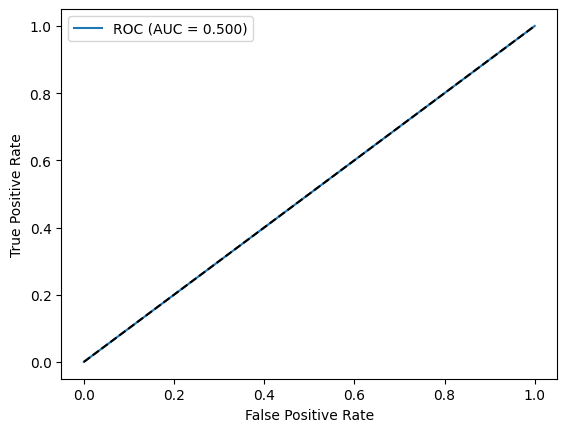

In [16]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities and compute ROC curve metrics
y_pred_proba = lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve with AUC score and diagonal reference line
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')

# Add axis labels, legend, and display the plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()